# Estudio comparativo de la familia de algoritmos de Ascenso de Gradiente

## Introducción

Dentro de todos los algoritmos existentes para resolver el problema del bandido de los k brazos, los de Ascenso de Gradiente se caracterizan por seleccionar la siguiente acción a realizar con base en una distribución de probabilidad. En dicha distribución, la probabilidad de seleccionar cada acción en el paso $t$ es proporcional a un determinado valor, que puede ser simplemente el valor de su recompensa esperada $Q_t(a)$. En ese caso, se trata del algoritmo **Softmax**, en el que la probabilidad de escoger la acción $a$ en el paso $t$ se calcula de la siguiente manera:

$$ \text{Softmax: } P(A_t = a) = \pi_t(a) = \dfrac{e^{Q_t(a) / \tau}}{\sum_{b=1}^k e^{Q_t(b) / \tau}} , $$

donde $\tau$ es un parámetro que controla cuánta exploración o explotación se realiza: cuanto más alto ($>1$), más exploración, y cuando más bajo ($<1$), más explotación. Este parámetro también se suele denominar *temperatura*, y así es como nos referimos a él en el código.

En el caso de los algoritmos de **Gradiente de Preferencias** [[2]](#apuntes), la distribución de probabilidad no se calcula a partir de la recompensa esperada, sino de una *preferencia* numérica $H_t(a)$. Así, la probabilidad de elegir cada acción $a$ en el paso $t$ se calcula de la siguiente forma:

$$ \text{PreferenceGradient: } P(A_t = a) = \pi_t(a) = \dfrac{e^{H_t(a)}}{\sum_{b=1}^k e^{H_t(b)}} . $$

Como se observa en la fórmula, en este algoritmo se prescinde del parámetro $\tau$. Inicialmente, todas las preferencias tienen el mismo valor (por ejemplo, $H_0(a) = 0 \ \forall a$) para que todas las acciones tengan la misma probabilidad de ser elegidas. En cada paso, tras seleccionar la acción $A_t$ y obtener la recompensa $R_t$, se deben actualizar las preferencias como sigue:

$$ H_{t+1}(A_t) = H_t(A_t) + \alpha (R_t - \bar{R}_t)(1-\pi_t(A_t)) , $$
$$ H_{t+1}(a) = H_t(a) - \alpha (R_t - \bar{R}_t)\pi_t(a) \quad \forall a \neq A_t , $$

donde $\alpha$ es un parámetro que controla el tamaño de las actualizaciones y $\bar{R}_t$ es la media de las recompensas obtenidas hasta el momento. Este valor sirve como línea base (*baseline*) a partir de la cual comparar la recompensa obtenida: si $R_t$ es mayor que el *baseline*, entonces la preferencia de $A_t$ aumenta, mientras que en caso contrario, la preferencia disminuye. Las preferencias de las acciones no seleccionadas se mueven en el sentido opuesto. 

En este estudio se analizarán y compararán los dos algoritmos explicados previamente, utilizando para cada uno tres tipos de bandidos diferentes: uno cuyos brazos seguirán una distribución normal, otro en el que seguirán una binomial y, por último, un bandido con distribución de Bernoulli. Primero, se establecerán un conjunto de parámetros comunes a todos los experimentos. A continuación, se crearán los tres tipos de bandidos. En las dos secciones principales se estudiará cómo de bien funciona cada algoritmo con cada tipo de bandido en términos de su recompensa promedio, arrepentimiento y porcentaje de selección del brazo óptimo. Por último, se hará una breve comparativa entre los dos algoritmos y se presentarán unas conclusiones finales.

## Preparación del entorno

In [ ]:
import os

if os.getenv("COLAB_RELEASE_TAG"):
    print("Ejecutando en Colab")
    !git clone https://github.com/mlucasumu/EML_RL_LucasOrtiz.git
    %cd EML_RL_LucasOrtiz/k_brazos
else:
   print("Ejecutando en local")

In [ ]:
# Librerías necesarias para el setup
import sys

# Añadir el directorio src al path para importar los módulos
src_path = os.path.abspath(os.path.join(os.getcwd(), 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)
    
print(sys.path)

['C:\\Users\\Marta\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'C:\\Users\\Marta\\AppData\\Local\\Programs\\Python\\Python312\\DLLs', 'C:\\Users\\Marta\\AppData\\Local\\Programs\\Python\\Python312\\Lib', 'C:\\Users\\Marta\\AppData\\Local\\Programs\\Python\\Python312', 'c:\\Users\\Marta\\Documents\\Mis_archivos\\Universidad\\Master\\2_cuatri\\Extensiones_ML\\eml-venv', '', 'c:\\Users\\Marta\\Documents\\Mis_archivos\\Universidad\\Master\\2_cuatri\\Extensiones_ML\\eml-venv\\Lib\\site-packages', 'c:\\Users\\Marta\\Documents\\Mis_archivos\\Universidad\\Master\\2_cuatri\\Extensiones_ML\\EML_RL_LucasOrtiz\\k_brazos\\src']


In [ ]:
# Importación de librerías y módulos
import numpy as np

from algorithms import Softmax, PreferenceGradient
from arms import Bandit, ArmNormal, ArmBinomial, ArmBernoulli
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics
from run_experiment import run_experiment

## Parámetros generales

En la siguiente celda se establecen algunos parámetros comunes a todos los experimentos, comenzando por una semilla para garantizar la reproducibilidad de los resultados. Hemos decidido utilizar bandidos de 6 brazos para que las gráficas de estadísticas de los brazos se puedan analizar con más facilidad. Cada ejecución constará de 300 pasos puesto que se comprobó que todos los algoritmos convergían antes de este número de iteraciones, y cada experimento será repetido 500 veces.

Es preciso mencionar que en el código de todos los algoritmos desarrollados se incluyó una primera fase de **inicialización** en la que el agente hace una primera vuelta por todos los brazos. Es decir, el algoritmo en sí mismo no comienza hasta que cada brazo se haya elegido una vez, puesto que se observó que esto mejoraba notablemente la convergencia.

In [4]:
SEMILLA = 1024

k = 6  # Número de brazos
steps = 300  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

## Creación de los bandidos

En esta sección se crean los tres bandidos que emplearemos para el estudio de ambos algoritmos, comenzando por el bandido cuyos brazos siguen una distribución normal. En cuanto a sus parámetros, los valores mínimo y máximo de la desviación estándar se han dejado por defecto (1 y 3, respectivamente), pero hemos decidido que las medias estén más próximas entre sí, moviéndose entre 5 y 10. De esta forma esperamos que al agente le cueste más tiempo determinar cuál es el brazo óptimo y la convergencia sea un poco más lenta, lo que nos permitirá observar las diferencias entre los diversos algoritmos con mayor claridad.

In [5]:
# Creación del bandit
np.random.seed(SEMILLA)
bandit_normal = Bandit(arms=ArmNormal.generate_arms(k, mu_min=5, mu_max=10)) # Generar un bandido con k brazos de distribución normal
print(bandit_normal)

optimal_arm_normal = bandit_normal.optimal_arm
print(f"Optimal arm: {optimal_arm_normal + 1} with expected reward={bandit_normal.get_expected_value(optimal_arm_normal)}")

Bandit with 6 arms: ArmNormal(mu=7.59, sigma=1.27), ArmNormal(mu=8.24, sigma=1.01), ArmNormal(mu=9.98, sigma=1.3), ArmNormal(mu=8.0, sigma=2.4), ArmNormal(mu=8.29, sigma=2.19), ArmNormal(mu=8.77, sigma=2.8)
Optimal arm: 3 with expected reward=9.98


Como vemos en la salida de la celda anterior, las medias se mueven entre $7.59$ y $9.98$, y las desviaciones, entre $1.01$ y $2.8$. El mejor brazo es el tercero con una recompensa esperada de $9.98$ (su valor medio).

Pasando al bandido con distribución binomial, en este caso hemos dejado el rango de probabilidades de éxito en su valor por defecto $([0.1,0.9])$, pero se ha establecido que el número de ensayos se mueva entre 5 y 15.

In [6]:
# Creación del bandit
np.random.seed(SEMILLA)
bandit_binomial = Bandit(arms=ArmBinomial.generate_arms(k, n_min=5, n_max=15)) # Generar un bandido con k brazos de distribución binomial
print(bandit_binomial)

optimal_arm_binomial = bandit_binomial.optimal_arm
print(f"Optimal arm: {optimal_arm_binomial + 1} with expected reward={bandit_binomial.get_expected_value(optimal_arm_binomial)}")

Bandit with 6 arms: ArmBinomial(n=6, p=0.58), ArmBinomial(n=6, p=0.7), ArmBinomial(n=10, p=0.22), ArmBinomial(n=14, p=0.21), ArmBinomial(n=6, p=0.1), ArmBinomial(n=5, p=0.66)
Optimal arm: 2 with expected reward=4.199999999999999


Las recompensas esperadas de estos bandidos (calculadas como $n\cdot p$) se encuentran entre $0.6$ y $4.2$, siendo el segundo brazo el óptimo.

Por último, creamos el bandido con brazos de distribución Bernoulli dejando los valores de probabilidad de éxito mínima y máxima a 0.1 y 0.9, respectivamente.

In [7]:
# Creación del bandit
np.random.seed(SEMILLA)
bandit_bernoulli = Bandit(arms=ArmBernoulli.generate_arms(k)) # Generar un bandido con k brazos de distribución Bernoulli
print(bandit_bernoulli)

optimal_arm_bernoulli = bandit_bernoulli.optimal_arm
print(f"Optimal arm: {optimal_arm_bernoulli + 1} with expected reward={bandit_bernoulli.get_expected_value(optimal_arm_bernoulli)}")

Bandit with 6 arms: ArmBernoulli(p=0.62), ArmBernoulli(p=0.9), ArmBernoulli(p=0.63), ArmBernoulli(p=0.58), ArmBernoulli(p=0.52), ArmBernoulli(p=0.7)
Optimal arm: 2 with expected reward=0.9


En esta ocasión, las recompensas esperadas están entre $0.52$ y $0.9$, y el mejor brazo es el segundo.

## Análisis de Softmax

Esta sección se dedica al estudio del algoritmo Softmax con los tres tipos de bandidos. Para cada uno, se ejecutarán tres versiones del algoritmo con valores diferentes del parámetro $\tau$ (temperatura). En particular, se probarán los valores $0.5$, $1$ y $2$.

In [41]:
algorithms_softmax = [Softmax(k=k, temp=0.5), Softmax(k=k, temp=1), Softmax(k=k, temp=2)] 

### Distribución Normal

En la siguiente celda se realiza la ejecución de los algoritmos con el bandido de distribución normal.

In [42]:
np.random.seed(SEMILLA)
rewards_SN, optimal_selections_SN, cumulative_regret_per_algo_SN, rewards_per_arm_per_algo_SN = run_experiment(bandit_normal, algorithms_softmax, steps, runs)

100%|██████████| 500/500 [00:25<00:00, 19.88it/s]


A continuación, mostraremos y comentaremos diversas gráficas que exponen el rendimiento de cada algoritmo a lo largo del tiempo.

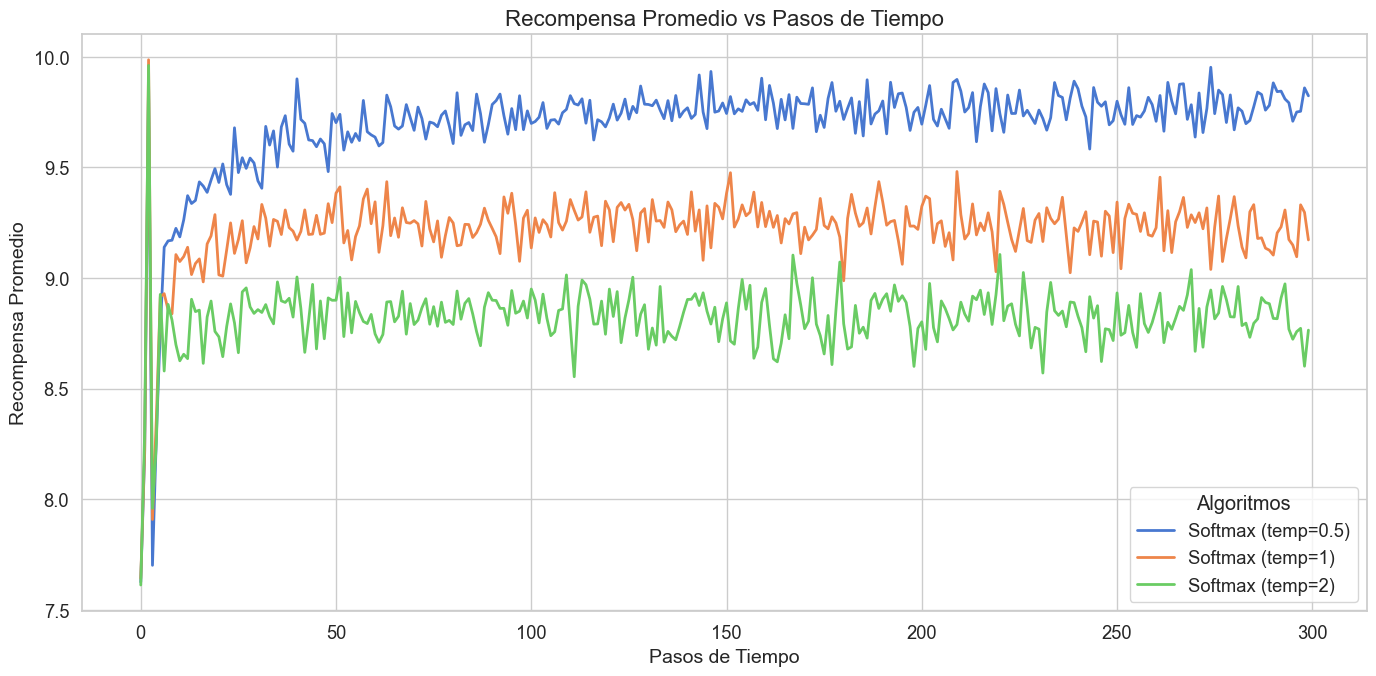

In [43]:
plot_average_rewards(steps, rewards_SN, algorithms_softmax)

La gráfica anterior muestra, para cada uno de los 300 pasos, el promedio de la recompensa obtenida en dicho paso entre las 500 ejecuciones. Cada algoritmo se muestra con un color diferente. Se observa una tendencia clara: a mayor valor de temperatura, menor rendimiento. Es decir, el algoritmo que ha logrado converger a una recompensa promedio más elevada es aquel cuya temperatura es igual a 0.5, mientras que el algoritmo de temperatura igual a 2 se ha estancado en la recompensa promedio más baja de entre los tres. 

En cuanto a la velocidad de convergencia, los tres presentan casi la misma: se aprecia que a partir de la iteración 15, aproximadamente, la recompensa promedio de cada algoritmo se estabiliza y deja de crecer. La única ligera excepción es el caso de $\text{Softmax}(temp=0.5)$, que parece seguir creciendo un poco después de que los otros dos se estabilicen.

Recordemos que a menor valor de temperatura, más se prima la *explotación*, así que en este algoritmo en particular parece ser beneficioso hacer más explotación que exploración. Probablemente esto se deba a que es un algoritmo capaz de hallar la solución óptima de manera más rápida que otros y, por tanto, no corremos el riesgo de estancarnos en una solución subóptima si priorizamos demasiado la explotación. Sin embargo, en el caso de que la temperatura sea muy alta, entonces la probabilidad de elegir un brazo subóptimo es demasiado elevada, a pesar de que quizás el bandido ya "sepa" qué brazo es mejor (en base a las recompensas promedio).

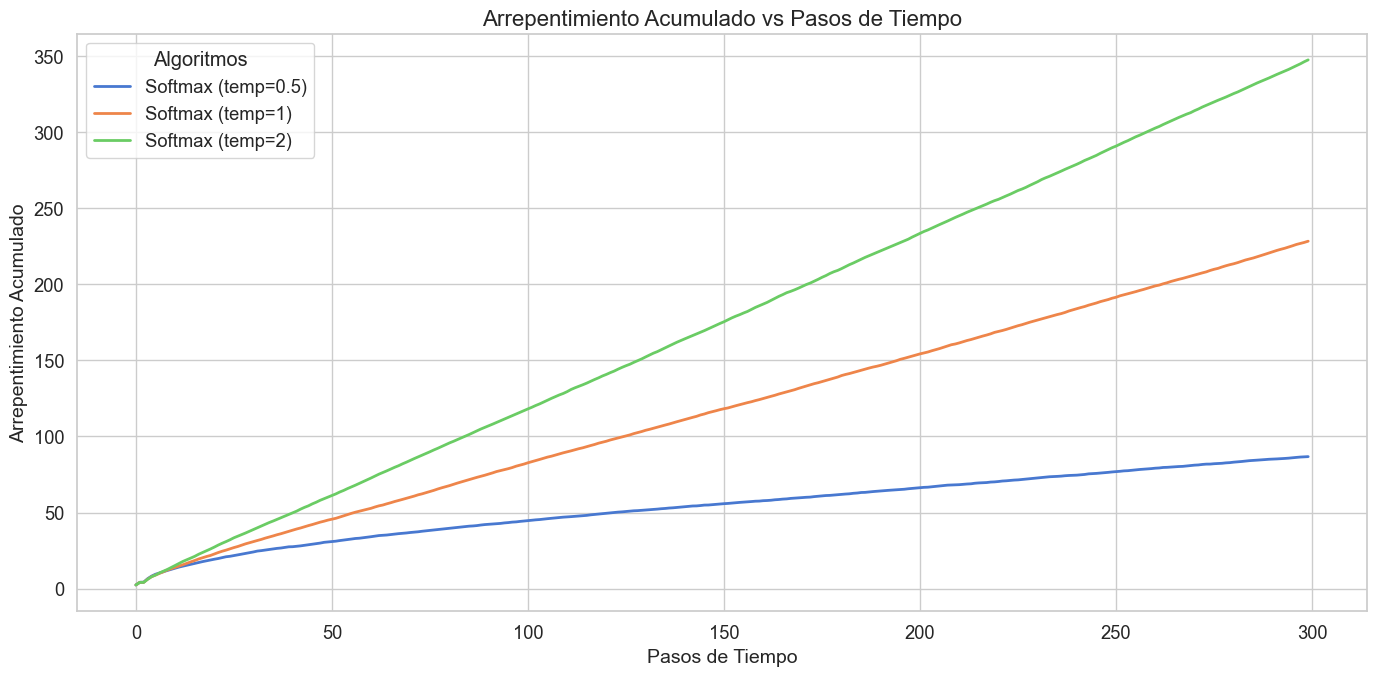

In [44]:
plot_regret(steps, cumulative_regret_per_algo_SN, algorithms_softmax)

La gráfica anterior muestra el arrepentimiento (*regret*) acumulado promedio en cada paso de tiempo para cada uno de los tres algoritmos. Recordemos que el arrepentimiento cuantifica la pérdida por no elegir siempre el brazo óptimo. En el mejor de los casos, si se eligiera siempre el brazo óptimo, el arrepentimiento promedio sería 0. En caso de que a partir de una cierta iteración se eligiera siempre el brazo óptimo, entonces deberíamos ver cómo, a partir de esa iteración, la curva se vuelve totalmente horizontal, puesto que el arrepentimiento dejaría de aumentar en las iteraciones sucesivas. Habitualmente, el arrepentimiento acumulado tiene una forma logarítmica.

Lo que apreciamos en esta gráfica complementa perfectamente a la gráfica de recompensas promedio: el algoritmo con temperatura igual a 2 se estancó en la peor solución de entre los tres y, por tanto, su arrepentimiento acumulado crece de una manera casi lineal: a partir de la iteración 15, aproximadamente, en cada paso sucesivo la diferencia entre el valor óptimo y el valor obtenido es prácticamente la misma, de modo que se va sumando siempre casi la misma cantidad. Sin embargo, en el algoritmo $\text{Softmax}(temp=0.5)$, observamos que su gráfica de arrepentimiento muestra una forma bastante más horizontal, lo que significa que en cada paso el arrepentimiento instantáneo es menor. Además, su curva se encuentra en valores bastante inferiores que los de los otros dos algoritmos, ya que ha logrado llegar a una mayor recompensa promedio.

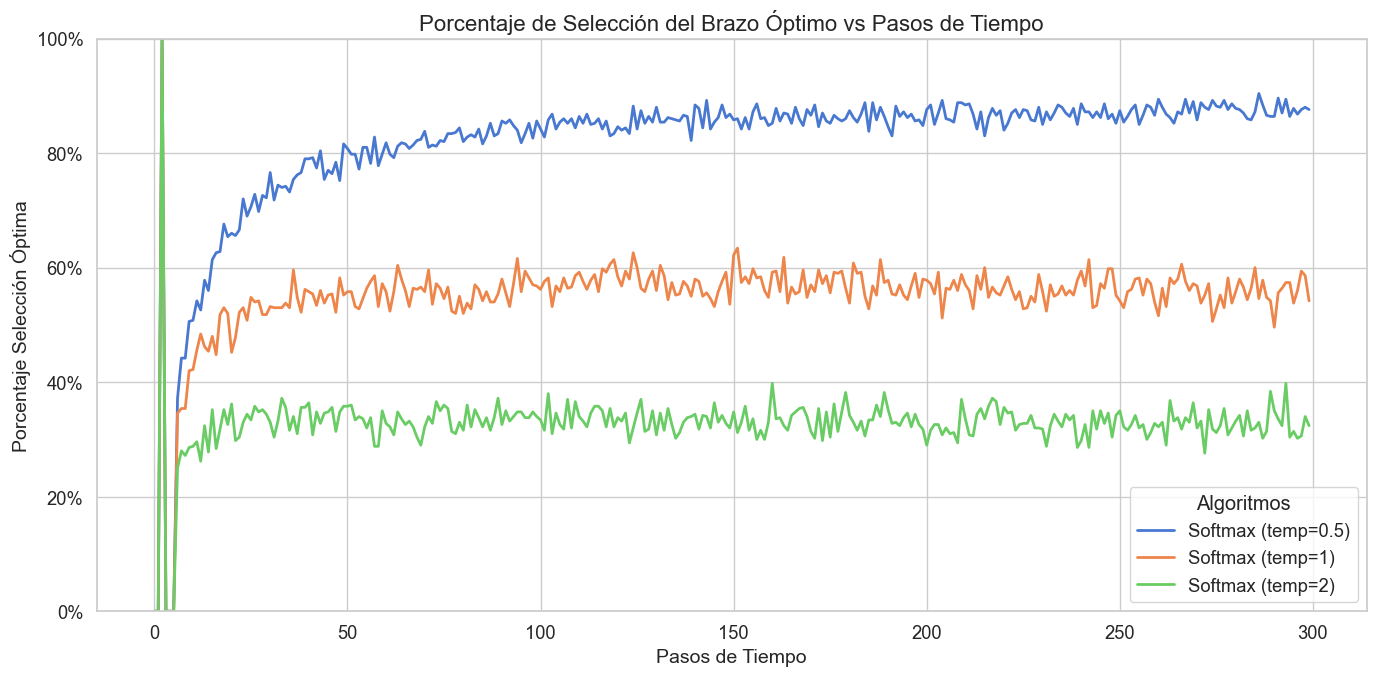

In [45]:
plot_optimal_selections(steps, optimal_selections_SN, algorithms_softmax)

En la gráfica anterior se muestra el porcentaje de veces, de entre las 500 ejecuciones, que el bandido escogió el brazo óptimo. Como cabría esperar, sigue una tendencia similar a la primera gráfica analizada: el mejor de los algoritmos, $\text{Softmax}(temp=0.5)$, escoge la acción óptima en un mayor porcentaje de las veces, y precisamente por eso es capaz de llegar a una mayor recompensa promedio. En concreto, una vez estabilizado, logra elegir la mejor acción en más del 80% de las ejecuciones en cada uno de los pasos, mientras que el algoritmo $\text{Softmax}(temp=1)$ se estanca alrededor del 60% y el $\text{Softmax}(temp=2)$, en algo más de un 30% de las veces.

También se aprecia en esta gráfica como el algoritmo de temperatura igual a 0.5, que hace menos exploración, tarda más en converger a una solución (aprende más lentamente).

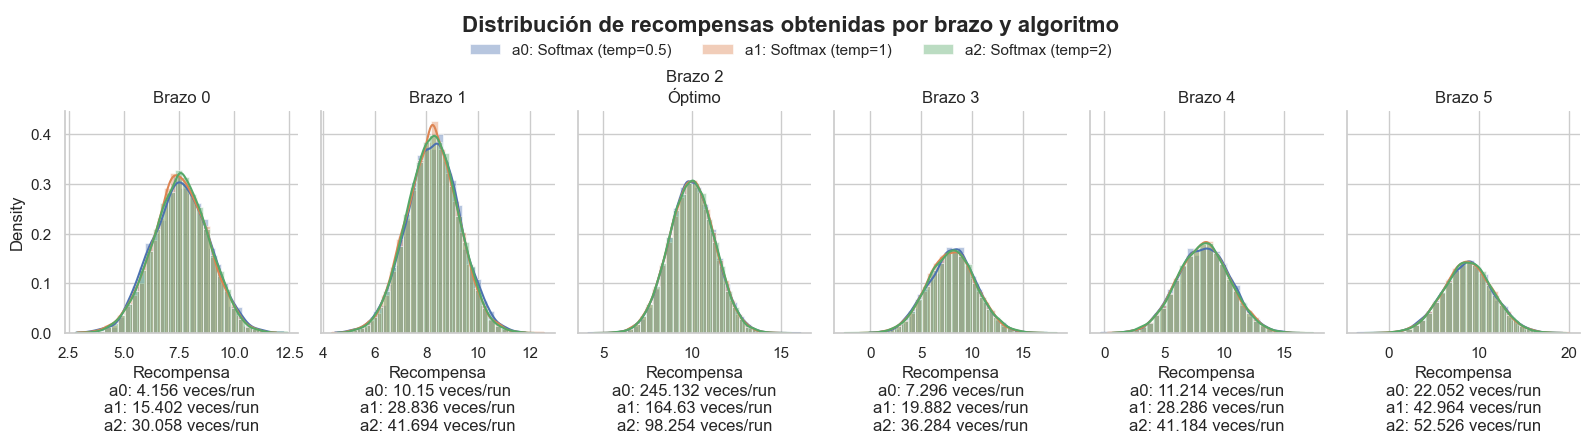

In [46]:
plot_arm_statistics(rewards_per_arm_per_algo_SN, algorithms_softmax, runs, optimal_arm_normal)

La última gráfica que mostramos es un desglose de la distribución de recompensas obtenidas con cada brazo y algoritmo. Para cada brazo se muestra un histograma que representa la distribución de recompensas obtenidas entre todas las veces que se escogió dicho brazo. Se muestran los tres algoritmos en capas, pero dado que las distribuciones son muy parecidas en los tres casos, no se llegan a distinguir (a excepción de algún pico en los brazos 0 y 1). Se indica cuál es el brazo óptimo y, además, en la parte inferior de las gráficas se dice el promedio de veces que el bandido ha escogido cada brazo, en cada algoritmo.

Como vemos, el brazo 2 es el óptimo y, en consecuencia, es el que más se ha elegido en los tres algoritmos. Sin embargo, vemos que en el mejor de los algoritmos ese brazo se ha escogido 246 veces de media, mientras que en el peor solo se ha escogido unas 98 veces en promedio. De hecho, en este último algoritmo (con temperatura igual a 2), el número de veces que se ha elegido cada brazo es bastante más equilibrado, mientras que el mejor algoritmo prioriza mucho más al mejor brazo y prácticamente ignora los demás. El segundo brazo más escogido por los algoritmos ha sido el brazo 5 dado que sus recompensas son también bastante elevadas, como vemos en el eje X del histograma (su media está también próxima a 10, pero su desviación típica aparenta ser mayor). 

### Distribución Binomial

Repitamos las mismas pruebas empleando el bandido de distribución binomial.

In [47]:
np.random.seed(SEMILLA)
rewards_SBi, optimal_selections_SBi, cumulative_regret_per_algo_SBi, rewards_per_arm_per_algo_SBi = run_experiment(bandit_binomial, algorithms_softmax, steps, runs)

100%|██████████| 500/500 [00:25<00:00, 19.37it/s]


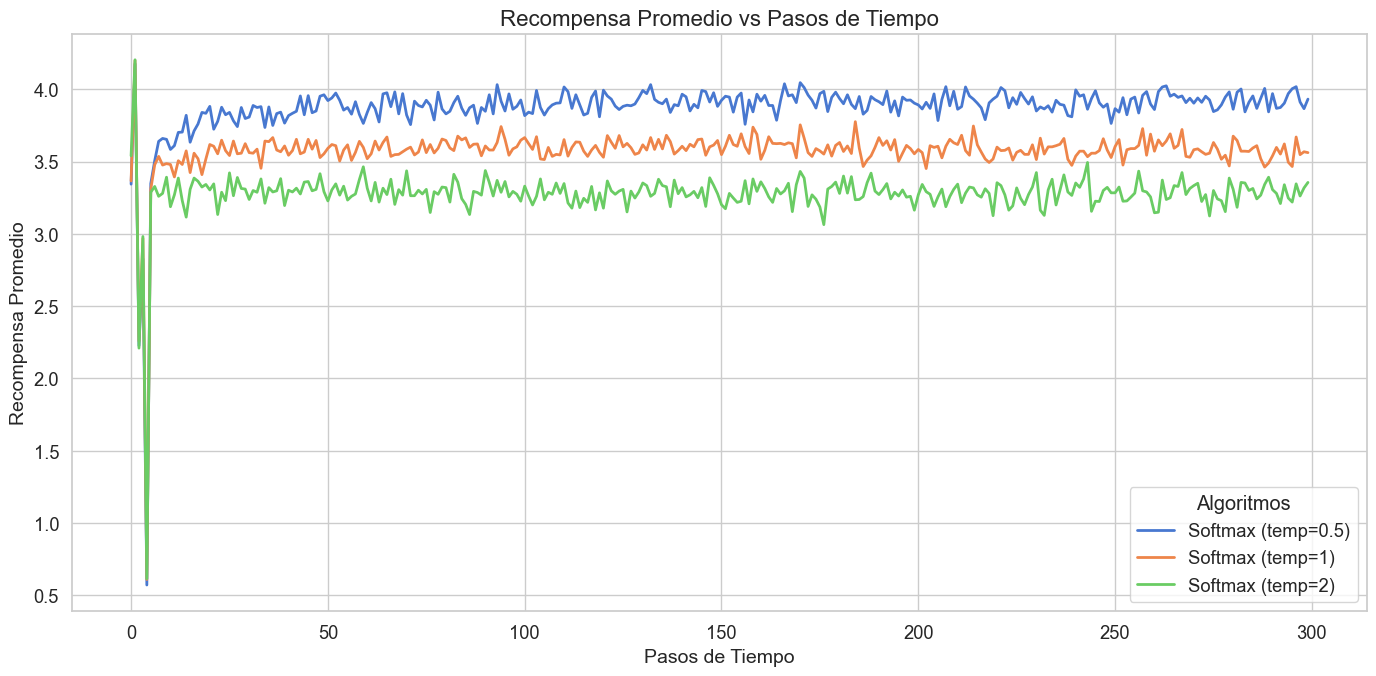

In [48]:
plot_average_rewards(steps, rewards_SBi, algorithms_softmax)

En cuanto a la gráfica de recompensas promedio, observamos que para este bandido el algoritmo Softmax parece funcionar mucho mejor, dado que las tres versiones han logrado dar con una solución próxima a la óptima (recordemos que el valor de la mejor recompensa era 4.2). De nuevo, el aprendizaje es muy rápido, pues parece que a partir de la iteración 10 o 15 los algoritmos dejan de aprender y se estancan en un valor de recompensa promedio. En este caso, la diferencia entre el mejor y el peor algoritmo no es tan pronunciada, siendo ésta de alrededor de 0.5. Aun así, el orden de los algoritmos se mantiene: a menor temperatura, mayor rendimiento.

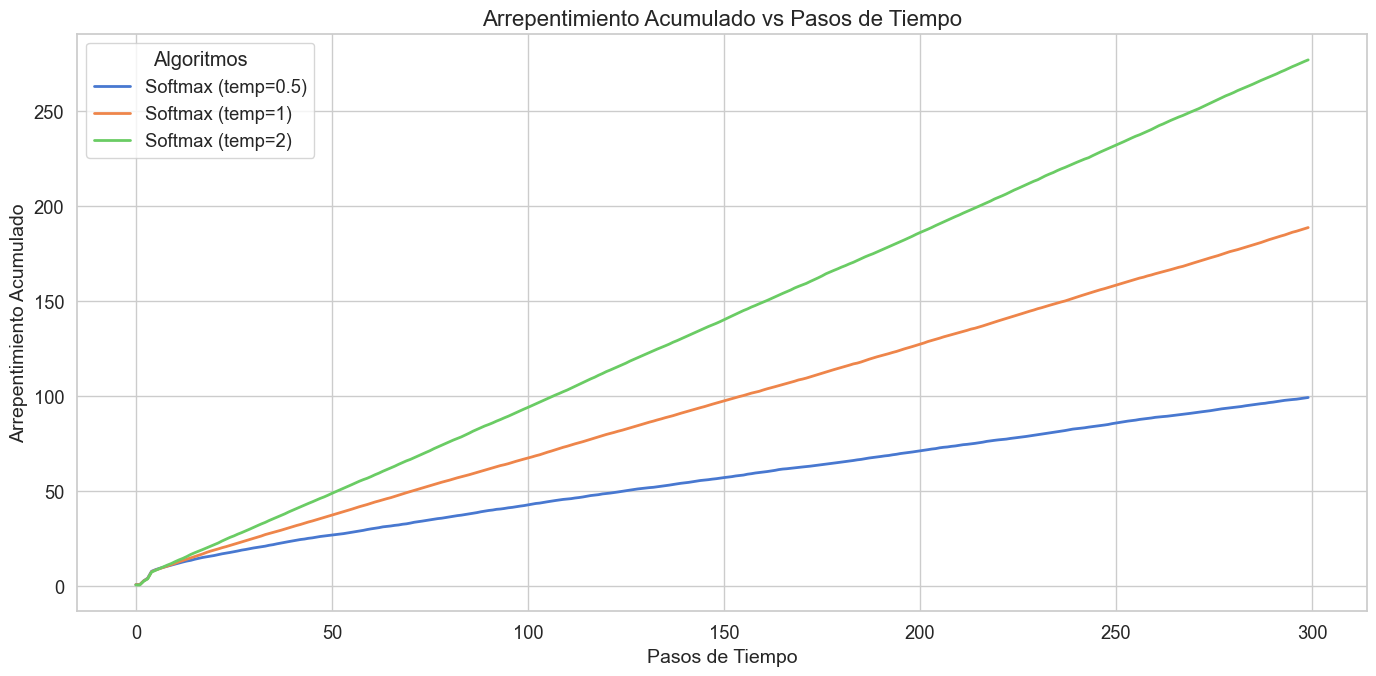

In [49]:
plot_regret(steps, cumulative_regret_per_algo_SBi, algorithms_softmax)

La gráfica de arrepentimiento acumulado es parecida al caso de las distribuciones normales: se trata de curvas logarítmicas, pero el mejor algoritmo presenta una curva más horizontal que los otros dos dados que la diferencia entre la recompensa obtenida en cada paso y la óptima es menor. También vemos que, a partir de una cierta iteración alrededor de la 10 o la 15, las curvas se vuelven prácticamente lineales dado que los algoritmos se han estancado en una solución y, por tanto, el arrepentimiento instántaneo en cada paso es casi igual.

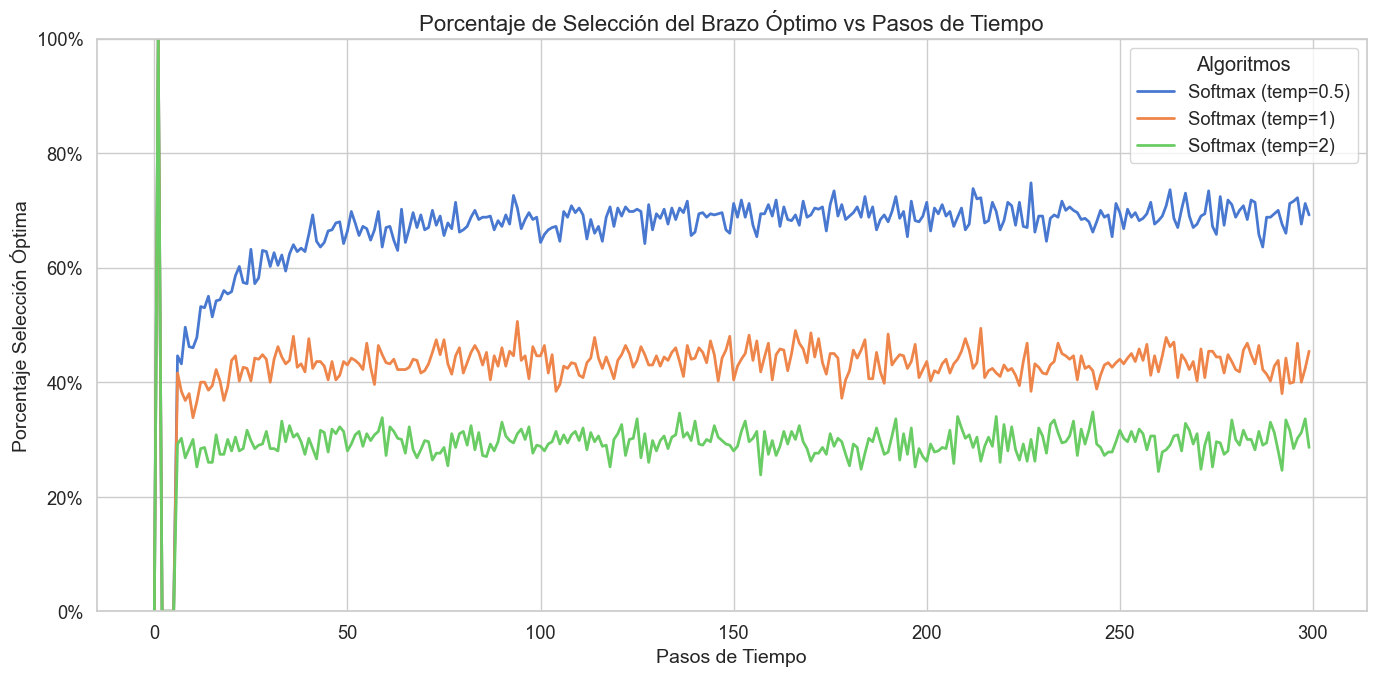

In [50]:
plot_optimal_selections(steps, optimal_selections_SBi, algorithms_softmax)

La gráfica de porcentaje de selección del brazo óptimo confirma lo que ya veíamos en la gráfica de recompensas promedio: el mejor algoritmo alcanza un mayor porcentaje de selección del brazo óptimo, de alrededor del 70% una vez estabilizado, y precisamente por eso logra tener una mayor recompensa promedio. El algoritmo con temperatura igual a 1 se estanca en un porcentaje cercano al 40% mientras que el peor se queda en un 30%. En esta gráfica vemos que la diferencia entre el mejor algoritmo y los otros dos es más pronunciada que en la primera gráfica y, además, se aprecia que $\text{Softmax}(temp=0.5)$ es el que más tarda en converger a una solución, como ya veíamos en la distribución normal. Los otros dos algoritmos, que priorizan más la explotación, aprenden más rápidamente pero se estancan en peores soluciones.

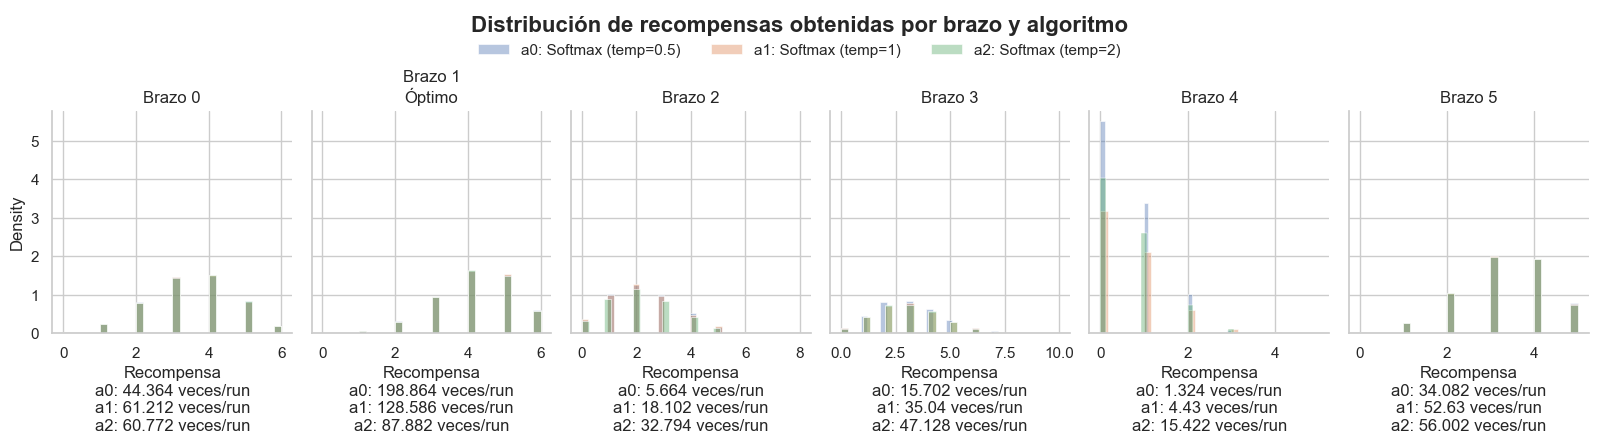

In [51]:
plot_arm_statistics(rewards_per_arm_per_algo_SBi, algorithms_softmax, runs, optimal_arm_binomial, kde=False)

En esta última gráfica volvemos a mostrar la distribución de recompensas obtenidas para cada brazo y algoritmo, indicando cuál es el brazo óptimo (el segundo en este caso) y el número medio de veces que cada brazo ha sido seleccionado en cada algoritmo. La única diferencia con respecto a los brazos de distribución normal es que en esta ocasión no se dibuja la curva de densidad por tratarse de una distribución con resultados discretos.

Como vemos, el mejor algoritmo prioriza mucho el brazo óptimo, escogiéndolo unas 200 veces de media, mientras que el segundo y tercer mejor brazo (0 y 5, respectivamente) solo han sido escogidos en 44 y 34 ocasiones cada uno. El peor algoritmo, por otra parte, ha repartido más el brazo escogido entre todos ellos, a expeción del peor (brazo 4), ya que éste era significativamente menos lucrativo que los demás, como vemos en su histograma, en el que se aprecia que la gran mayoría de las veces su recompensa era de 0 o de 1. El algoritmo $\text{Softmax}(temp=1)$ ha priorizado los brazos más lucrativos en mayor medida que $\text{Softmax}(temp=2)$, pero ha explorado bastante más que $\text{Softmax}(temp=0.5)$, escogiendo el segundo y tercer mejor brazo en 61 y 53 ocasiones de media, respectivamente.

### Distribución Bernoulli

Para finalizar con el algoritmo Softmax, veamos cómo se comporta con un bandido de distribución Bernoulli.

In [52]:
np.random.seed(SEMILLA)
rewards_SBe, optimal_selections_SBe, cumulative_regret_per_algo_SBe, rewards_per_arm_per_algo_SBe = run_experiment(bandit_bernoulli, algorithms_softmax, steps, runs)

100%|██████████| 500/500 [00:25<00:00, 19.78it/s]


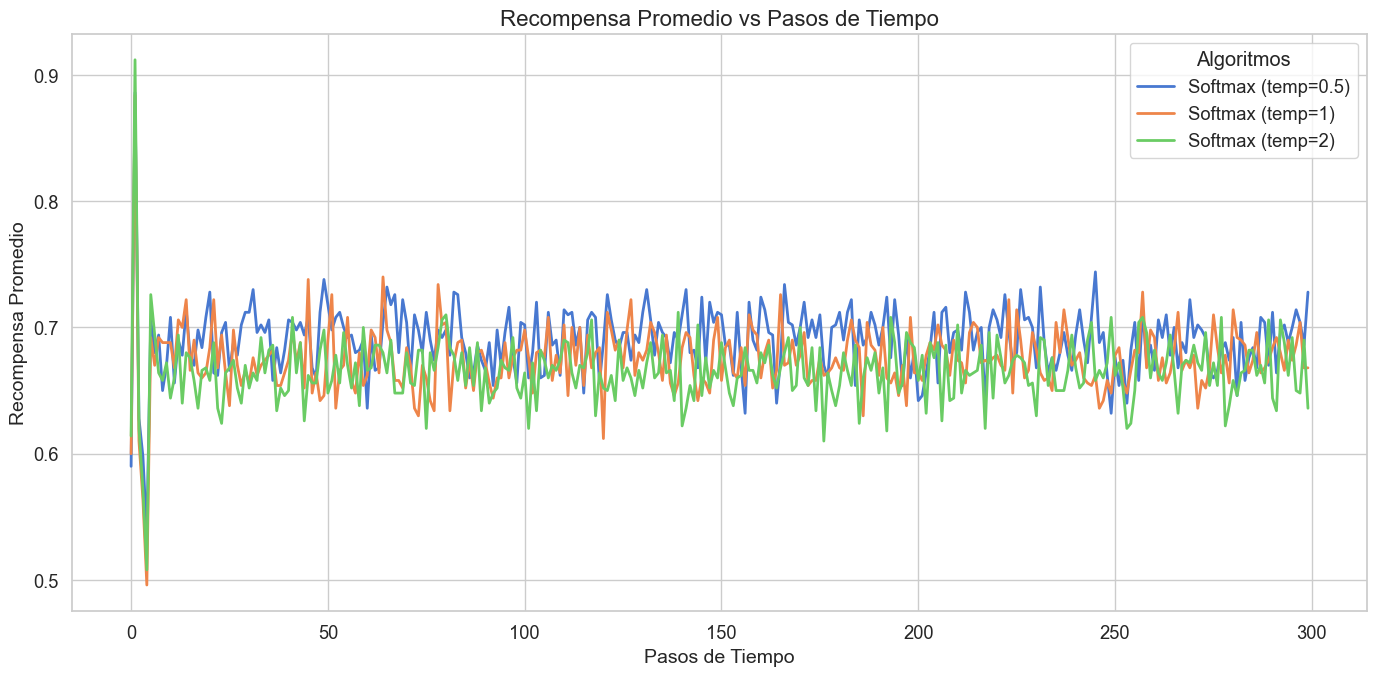

In [53]:
plot_average_rewards(steps, rewards_SBe, algorithms_softmax)

Curiosamente, en esta ocasión el resultado obtenido difiere mucho de los dos casos anteriores. A pesar de que la recompensa esperada óptima era de 0.9 (con el segundo brazo), ninguno de los algoritmos ha logrado acercarse a este resultado, estancándose todos en valores inferiores a 0.7. Ni siquiera $\text{Softmax}(temp=0.5)$ ha conseguido superar de manera notable a los otros dos algoritmos, como pasaba con los bandidos anteriores. A la vista de esta gráfica, no parece haber una diferencia significativa entre los tres valores de temperatura para este bandido en particular, lo que sugiere que el algoritmo Softmax no funciona muy bien para brazos con distribución Bernoulli. En cuanto a la velocidad de convergencia, es posiblemente la mayor que hemos visto hasta el momento, puesto que parece que los algoritmos se estabilizan incluso antes de la iteración número 10.

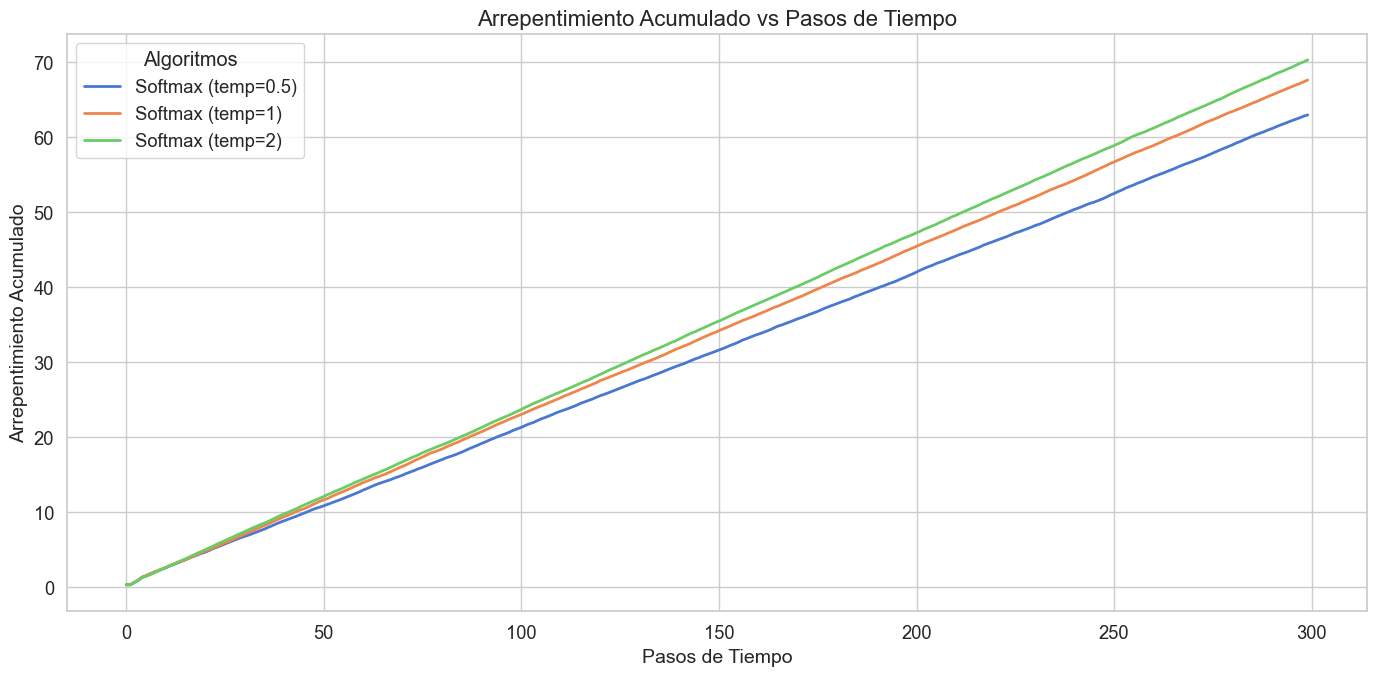

In [54]:
plot_regret(steps, cumulative_regret_per_algo_SBe, algorithms_softmax)

Como era de esperar, dado que los tres algoritmos se estancan rápidamente en casi la misma solución subóptima, sus curvas de arrepentimiento acumulado son muy parecidas entre sí, mostrando una forma prácticamente lineal. Aquí sí se puede apreciar mejor la diferencia entre los tres valores de temperatura, y vemos que el mejor algoritmo vuelve a ser el de temperatura 0.5, y el peor es el de temperatura 2. El mayor arrepentimiento acumulado obtenido por este último es de alrededor de 70 en 300 iteraciones, lo que implica que, de media, en cada paso la recompensa obtenida es de 0.23 $(70/300)$ menos que la óptima. Esto encaja con lo que veíamos en la anterior gráfica, en la que el peor algoritmo se estabilizaba en un valor algo inferior a 0.7, mientras que la recompensa esperada óptima era de 0.9. 

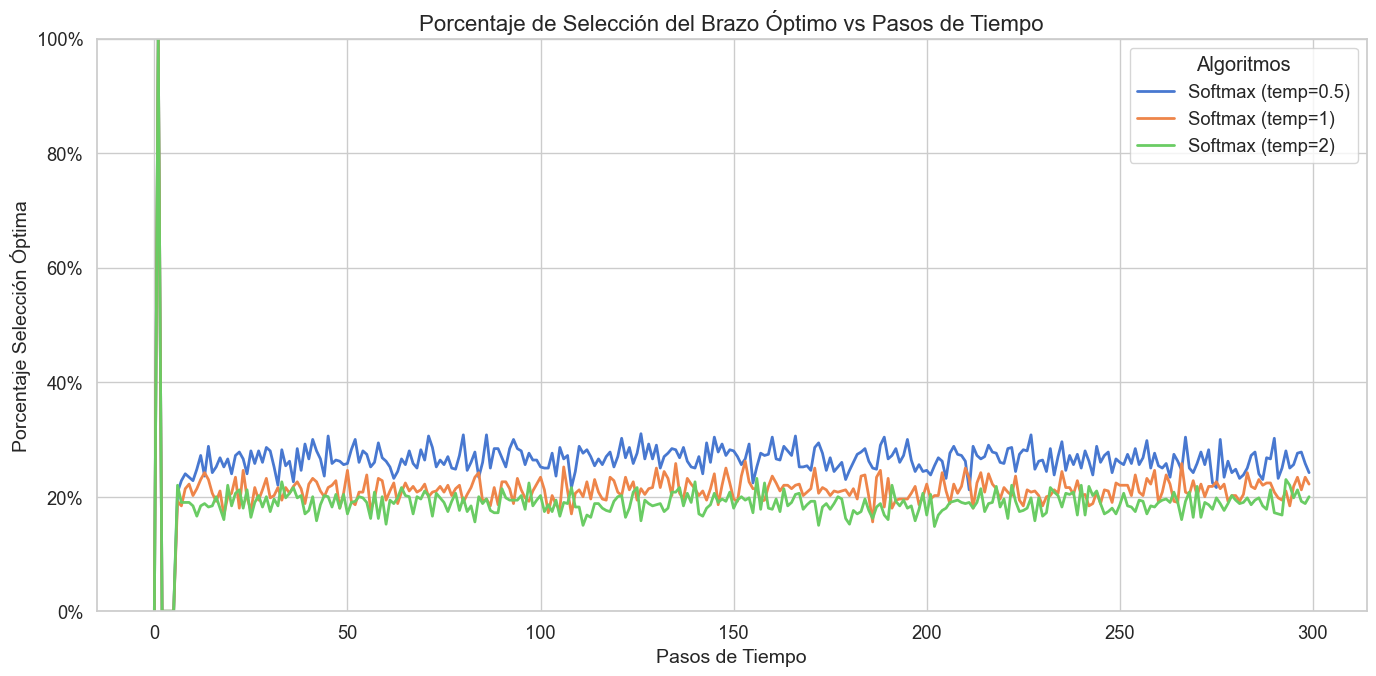

In [55]:
plot_optimal_selections(steps, optimal_selections_SBe, algorithms_softmax)

En relación con el porcentaje de selección del brazo óptimo, los tres algoritmos tienen un rendimiento muy bajo, situándose alrededor de un 20% una vez estabilizados. Observamos que $\text{Softmax}(temp=0.5)$ presenta un porcentaje ligeramente superior que los otros dos, pero claramente su rendimiento está muy por debajo del que alcanzaba con las distribuciones normal y binomial. Es decir, al algoritmo Softmax le resulta muy díficil determinar cuál es el brazo óptimo con este tipo de distribución (aunque, por supuesto, es posible que los valores concretos de $p$ que hemos generado sean particularmente problemáticos en este sentido, puesto que estaban bastante próximos entre sí).

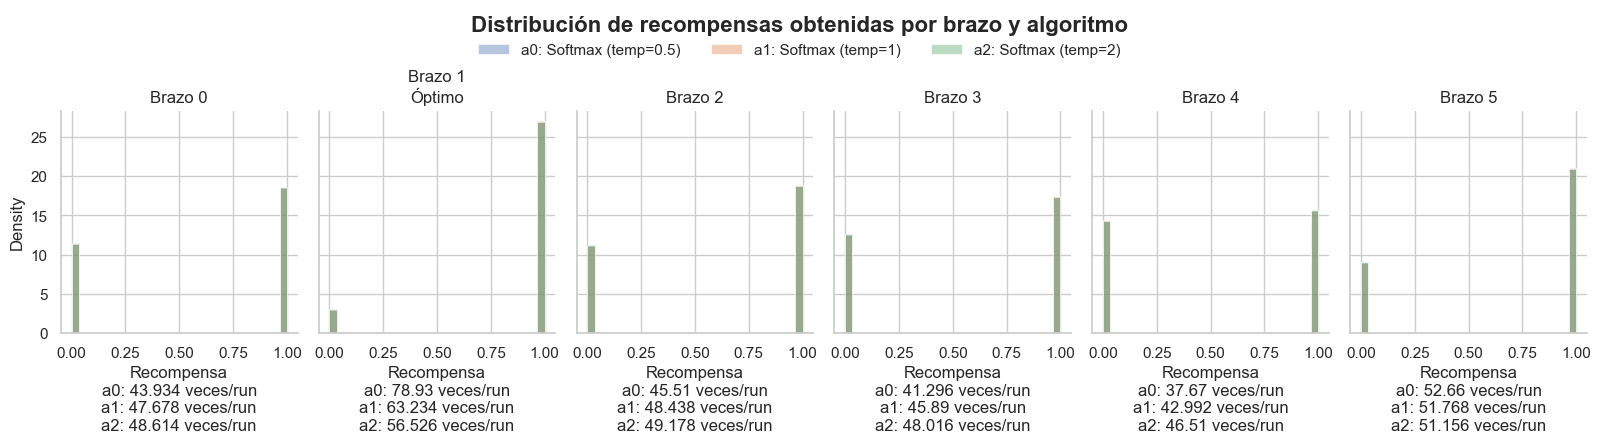

In [56]:
plot_arm_statistics(rewards_per_arm_per_algo_SBe, algorithms_softmax, runs, optimal_arm_bernoulli, kde=False)

Para finalizar, mostramos las estadísticas de cada brazo. En este caso, no hay tanta diferencia entre el número de veces que cada brazo ha sido escogido por cada algoritmo, especialmente entre los de temperatura 1 y 0.5. Sí que apreciamos una ligera priorización del brazo óptimo por parte del mejor algoritmo, pero no tan significativa como en las distribuciones anteriores. De hecho, los tres algoritmos han repartido de manera bastante equitativa sus acciones entre los 6 brazos.

Si bien es cierto que las distribuciones son parecidas entre sí, a la vista de los histogramas es evidente que el brazo 1 tiene una probabilidad de éxito bastante mayor que los otros, por lo que esperaríamos que alguno de los algoritmos Softmax hubiese sido capaz de darse cuenta de esto y realizar una mayor explotación de este brazo.

## Análisis de Gradiente de Preferencias

Esta sección se dedica al estudio del algoritmo de Gradiente de Preferencias con los tres tipos de bandidos. Para cada uno, se ejecutarán tres versiones del algoritmo con valores diferentes del parámetro $\alpha$. Probaremos con los mismos valores que le dimos a la temperatura en el algoritmo Softmax: $0.5$, $1$ y $2$.

In [25]:
algorithms_gradient = [PreferenceGradient(k=k, alpha=0.5), PreferenceGradient(k=k, alpha=1), PreferenceGradient(k=k, alpha=2)]

### Distribución Normal

En primer lugar, ejecutamos los tres algoritmos con el bandido cuyos brazos siguen una distribución normal.

In [26]:
np.random.seed(SEMILLA)
rewards_GN, optimal_selections_GN, cumulative_regret_per_algo_GN, rewards_per_arm_per_algo_GN = run_experiment(bandit_normal, algorithms_gradient, steps, runs)

100%|██████████| 500/500 [00:32<00:00, 15.22it/s]


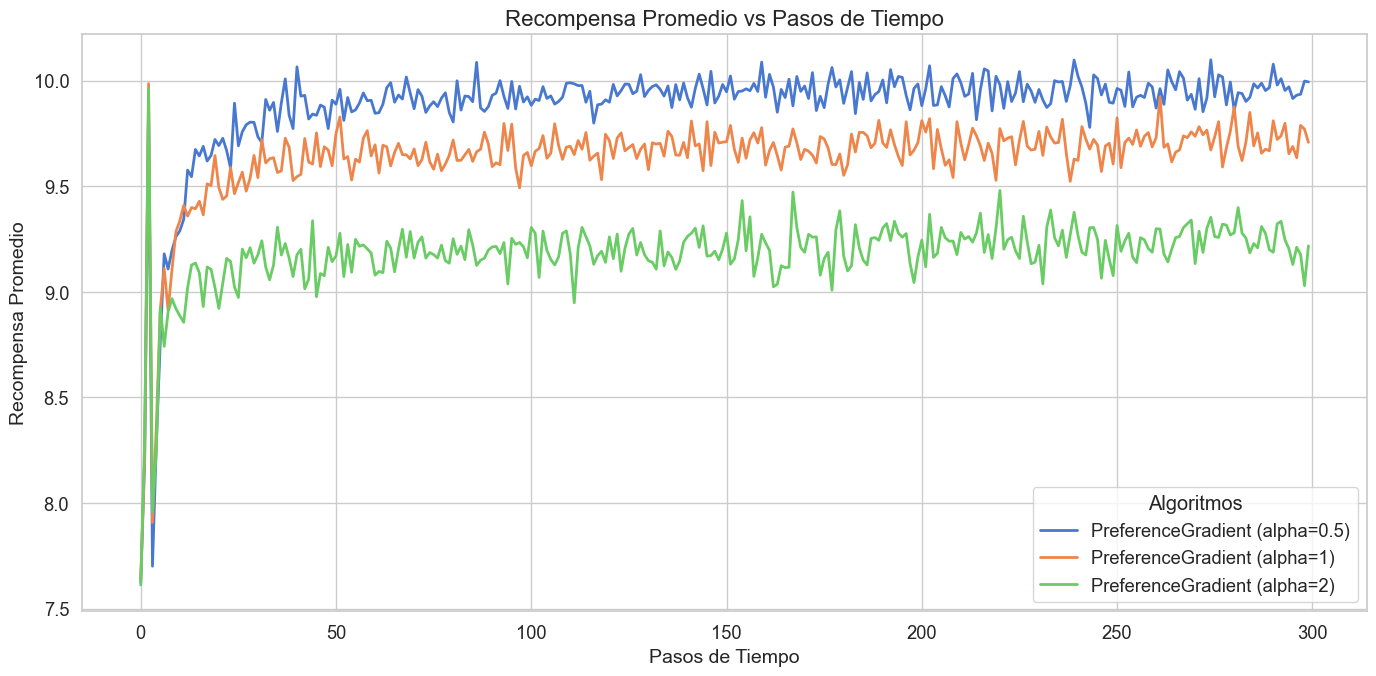

In [27]:
plot_average_rewards(steps, rewards_GN, algorithms_gradient)

In [57]:
bandit_normal.get_expected_rewards()

[7.59, 8.24, 9.98, 8.0, 8.29, 8.77]

En la gráfica de recompensas promedio observamos una tendencia muy similar a la que veíamos en el algoritmo Softmax: los mayores valores de $\alpha$ dan lugar a un menor rendimiento y, por ende, el mejor algoritmo de los tres es aquel con un menor valor de $\alpha$ (concretamente, de 0.5). Aunque a simple vista la forma de la gráfica parece casi igual que para los algoritmos Softmax, en realidad los algoritmos de Gradiente de Preferencias funcionan mejor con estos parámetros:

- Mientras que $\text{Softmax}(temp=0.5)$ se estabilizaba en un valor alrededor de 9.75, $\text{PreferenceGradient}(alpha=0.5)$ ha logrado llegar a una recompensa promedio de casi 10 una vez ha convergido. Recordemos que la máxima recompensa esperada en este caso era de 9.98 con el tercer brazo.
- El algoritmo $\text{Softmax}(temp=1)$ convergía en una recompensa promedio inferior a 9.5, mientras que $\text{PreferenceGradient}(alpha=1)$ supera este valor.
- El peor de los algoritmos de Gradiente de Preferencias es capaz de superar una recompensa promedio de 9.0, mientras que en el caso del Softmax éste se estancaba en valores que oscilaban entre 8.6 y 8.9, aproximadamente.

En cuanto a la velocidad de aprendizaje, los tres algoritmos parecen tener aproximadamente la misma, estabilizándose a partir de la iteración 15 o 20, aunque $\text{PreferenceGradient}(alpha=2)$ aparenta converger incluso un poco más rápido que los otros dos.

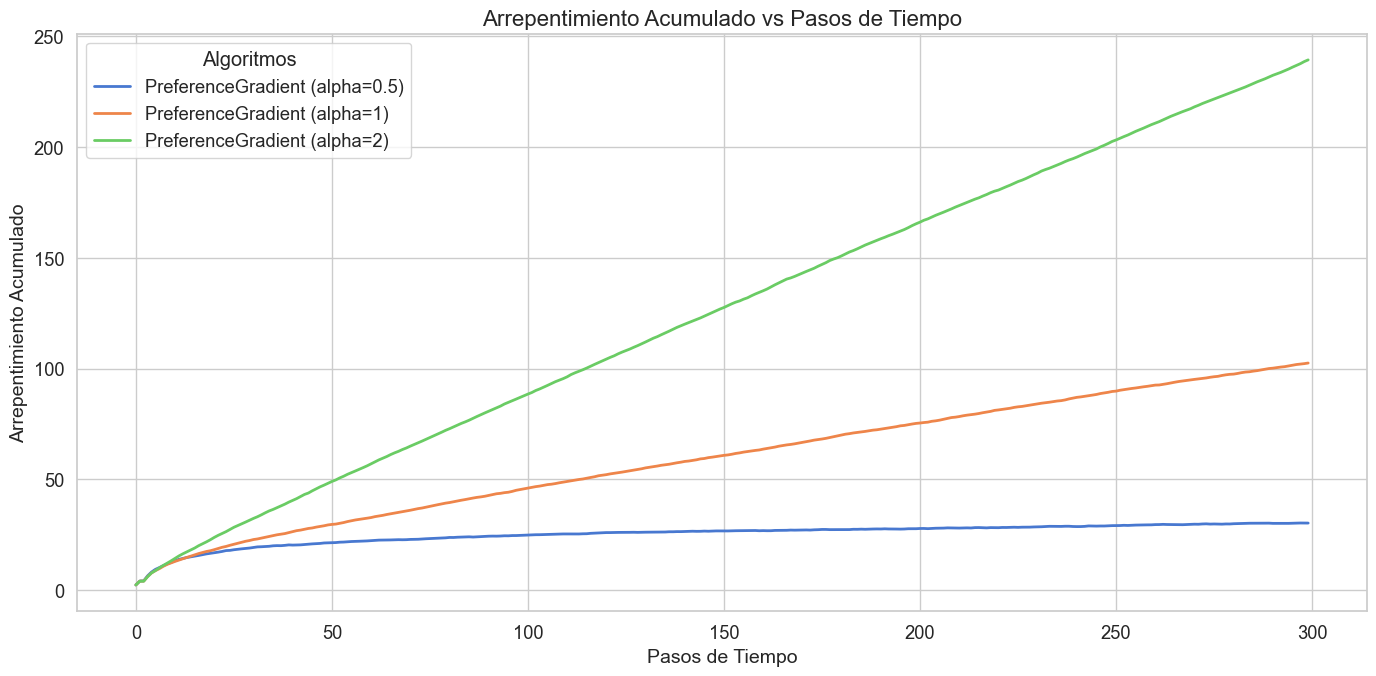

In [28]:
plot_regret(steps, cumulative_regret_per_algo_GN, algorithms_gradient)

En esta gráfica también apreciamos las diferencias que comentábamos previamente con respecto a los algoritmos Softmax: las curvas de arrepentiemiento, particularmente con los valores de $\alpha$ de 0.5 y 1, son mucho más horizontales, indicando que estos algoritmos son capaces de obtener recompensas promedio más cercanas a la óptima a partir de cierto paso. Además, como se estabilizan en una iteración muy baja, las curvas aparentan ser prácticamente lineales en su totalidad, y casi no se aprecia una forma logarítmica más que al principio.

Mientras que el máximo arrepentimiento acumulado en este caso es de algo menos de 250, en los algoritmos Softmax este valor llegaba a casi 350. En cuanto al mejor de los algoritmos, su arrepentimiento acumulado en la iteración 300 es de poco más de 25, mientras que en $\text{Softmax}(temp=2)$ llegaba a ser casi 100.

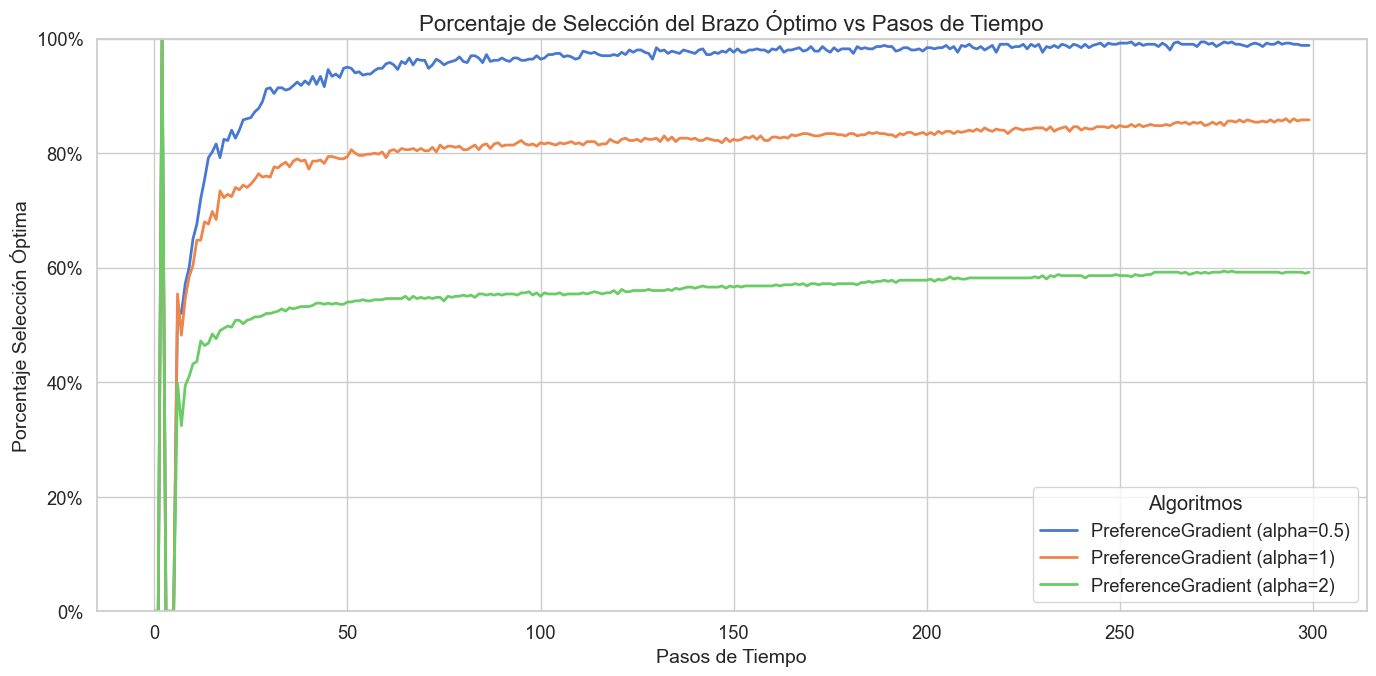

In [29]:
plot_optimal_selections(steps, optimal_selections_GN, algorithms_gradient)

Como cabría esperar, el algoritmo con $\alpha=0.5$ alcanza un porcentaje de selección del brazo óptimo de casi el 100% en sus últimas iteraciones y, además, se aprecia que este porcentaje va aumentando progresivamente durante toda la ejecución (de hecho, así lo hace en los tres algoritmos). El segundo mejor algoritmo también logra alcanzar un porcentaje de selección del brazo óptimo bastante elevado, de aproximadamente el 85%, mientras que el peor se queda en algo menos del 60%. De nuevo, notamos que estos algoritmos alcanzan resultados mucho mejores que los Softmax en términos del porcentaje de selección del brazo óptimo, por ejemplo, el peor de los algoritmos Softmax no llegaba a un 40%, mientras que en este caso se queda cerca del 60%. Además, otro detalle interesante es que mientras que los Softmax parecían estancarse y dejar de mejorar a partir de cierto punto, estos no dejan de mejorar durante todo el proceso.

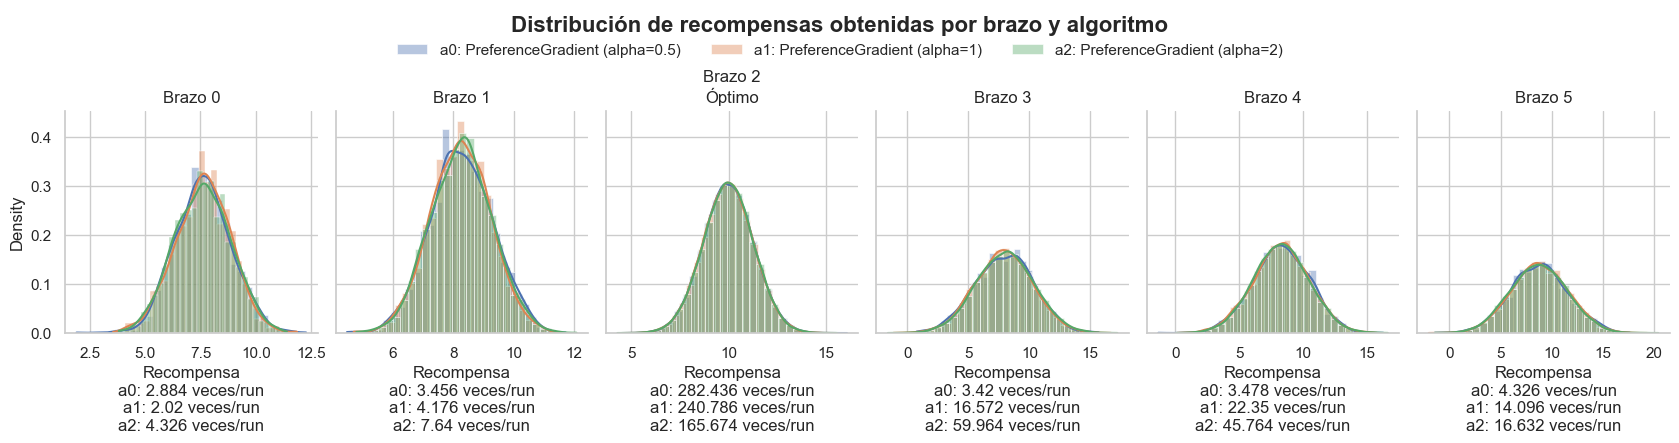

In [30]:
plot_arm_statistics(rewards_per_arm_per_algo_GN, algorithms_gradient, runs, optimal_arm_normal)

En relación con las estadísticas de cada brazo, vemos en primer lugar que las tres versiones del algoritmo priorizan mucho más el brazo óptimo que los Softmax. Lógicamente, el algoritmo con $\alpha=2$ es el que más reparte sus acciones entre los brazos, pero lo hace sobre todo entre los tres primeros, mientras que en los Softmax elegía también los tres peores brazos con frecuencia. En cuanto al mejor de los algoritmos, observamos que solo ha elegido los brazos subóptimos unas 3 o 4 veces de media, y el resto de acciones han sido tirar del brazo óptimo. Otro detalle curioso es que en esta ocasión se aprecian más picos en los histogramas, probablemente debidos a que, como hay brazos que se han elegido muy pocas veces en cada algoritmo, las distribuciones resultantes no son del todo representativas de sus distribuciones teóricas.

### Distribución Binomial

Pasemos ahora a probar los algoritmos de Gradiente de Preferencias con el bandido de distribución binomial.

In [31]:
np.random.seed(SEMILLA)
rewards_GBi, optimal_selections_GBi, cumulative_regret_per_algo_GBi, rewards_per_arm_per_algo_GBi = run_experiment(bandit_binomial, algorithms_gradient, steps, runs)

100%|██████████| 500/500 [00:33<00:00, 15.01it/s]


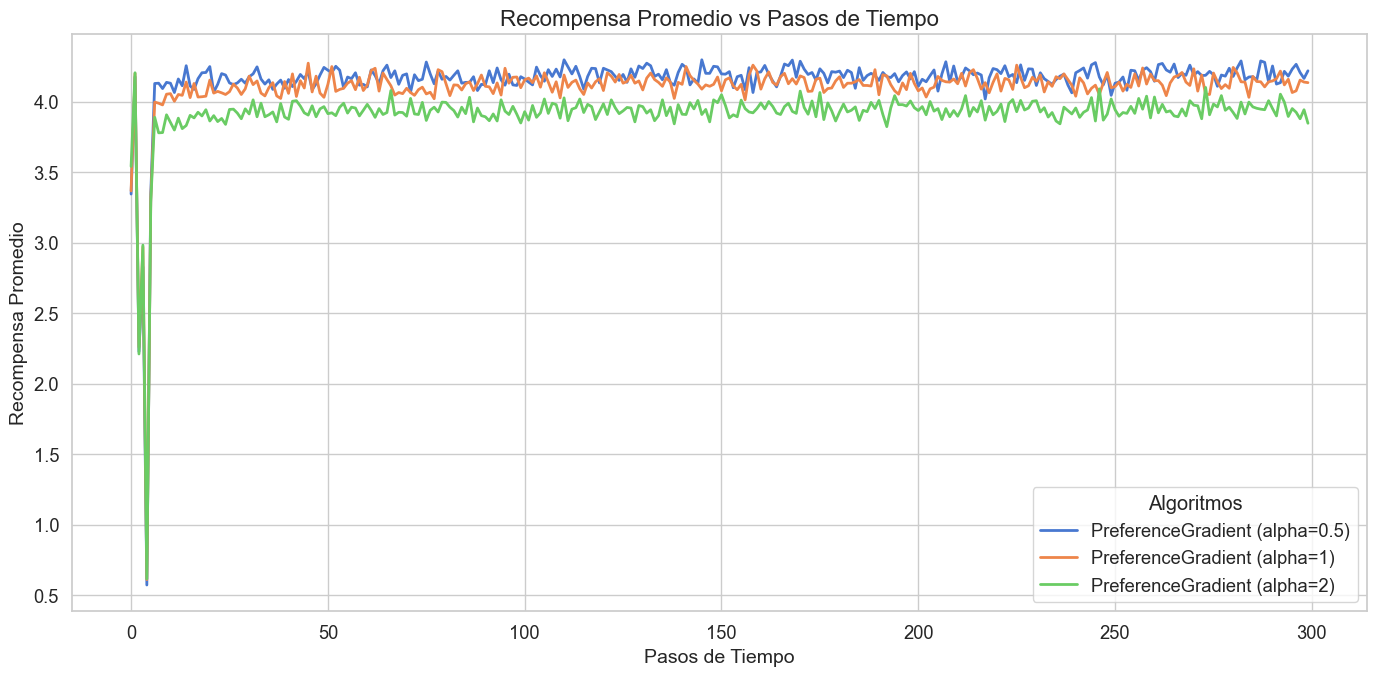

In [32]:
plot_average_rewards(steps, rewards_GBi, algorithms_gradient)

Los resultados obtenidos en cuanto a recompensas promedio son excepcionalmente buenos para las tres versiones, pero sobre todo para los valores de $\alpha$ igual a 0.5 y 1. En este bandido la mejor recompensa esperada era de 4.2 con el segundo brazo, y podemos ver que los dos algoritmos antedichos logran llegar a recompensas promedio alrededor de ese valor óptimo. Además, la velocidad de convergencia parece ser bastante más rápida que con la distribución normal. Incluso el peor de los algoritmos alcanza recompensas promedio muy elevadas, rozando el valor de 4.0.

Si lo comparamos con Softmax, este algoritmo ha sido capaz de converger a una mejor solución para las tres parametrizaciones. En el mejor de los casos, la recompensa es esencialmente la óptima (4.2), mientras que en Softmax se quedaba en algo menos de 4.0. En el peor de los casos, la recompensa promedio obtenida en cada paso es de unos 4.0, cuando el Softmax se estancaba en valores inferiores a 3.5.

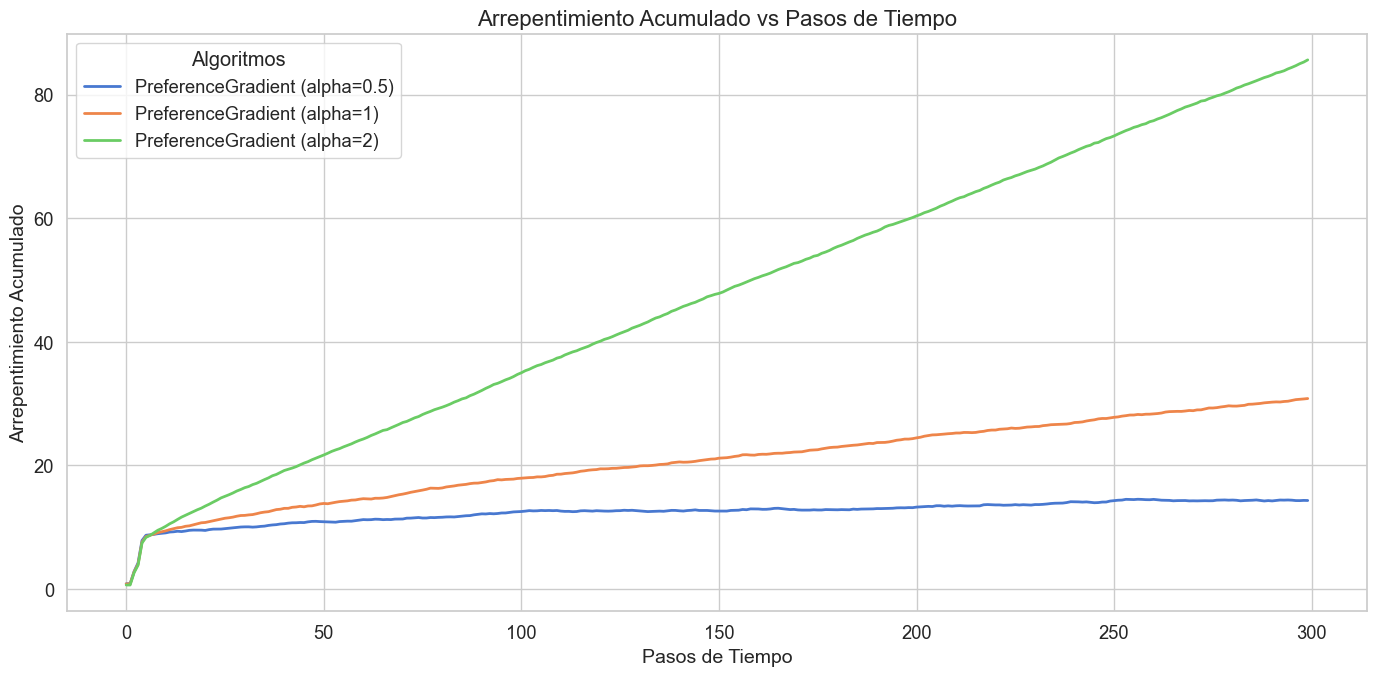

In [33]:
plot_regret(steps, cumulative_regret_per_algo_GBi, algorithms_gradient)

En la gráfica de arrepentimiento acumulado se aprecia que este valor crece rápidamente en las primeras 10 iteraciones, pero inmediatamente después (una vez los algoritmos han convergido) las curvas adquieren una forma casi horizontal, en especial en el caso de $\text{PreferenceGradient}(alpha=0.5)$, que prácticamente deja de crecer y se queda en un valor de alrededor de 10 (mientras que en Softmax este valor era de casi 100 en la última iteración). En el peor de los casos, el arrepentimiento acumulado llega a tener un valor de ~90 en la última iteración, y en el peor de los algoritmos Softmax este valor se acercaba a ser 300.

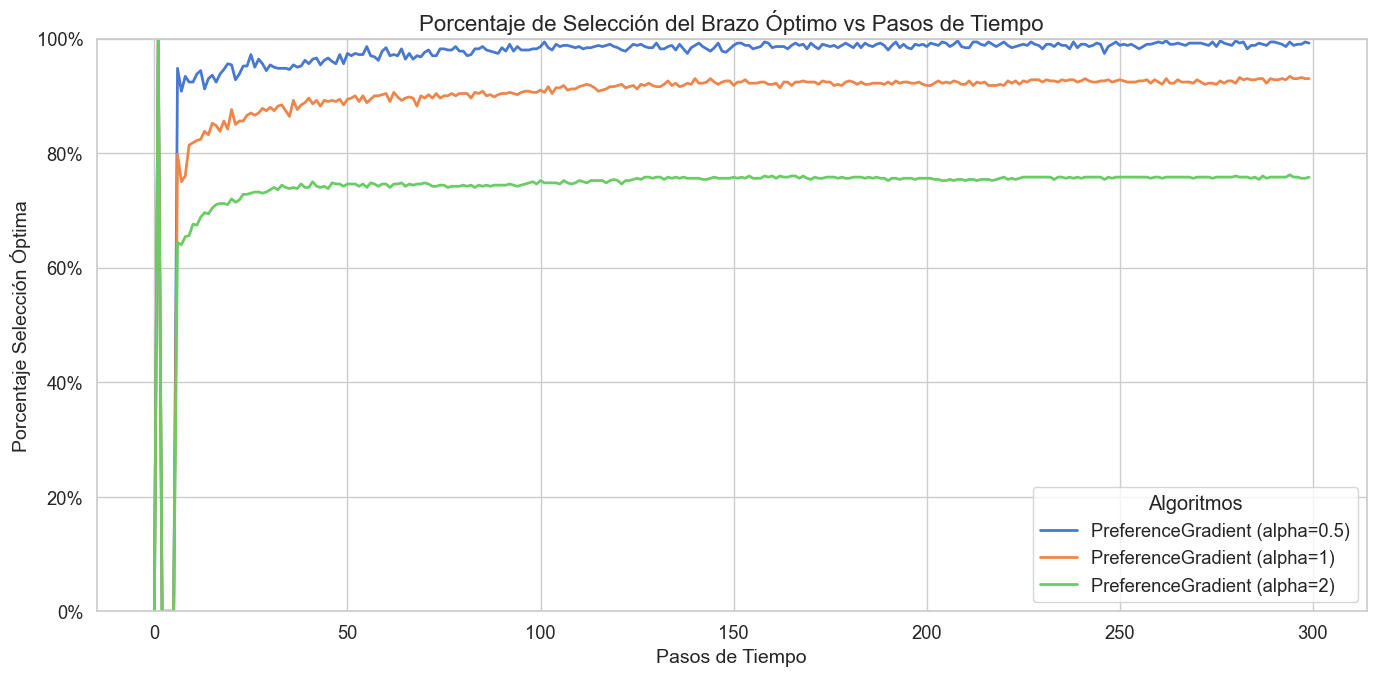

In [34]:
plot_optimal_selections(steps, optimal_selections_GBi, algorithms_gradient)

Al igual que pasaba con el bandido de distribución normal, el mejor de los algoritmos de gradiente de preferencias también alcanza un porcentaje de selección del brazo óptimo muy cercano al 100% en los últimos pasos, y el segundo mejor algoritmo se le acerca bastante, quedándose por encima del 90%. Esto son resultados notablemente mejores que en Softmax, cuyo mejor algoritmo apenas llegaba al 70% de selección del brazo óptimo una vez estabilizado. De hecho, el peor de los algoritmos de Gradiente de Preferencias supera al mejor algoritmo de Softmax en este respecto.

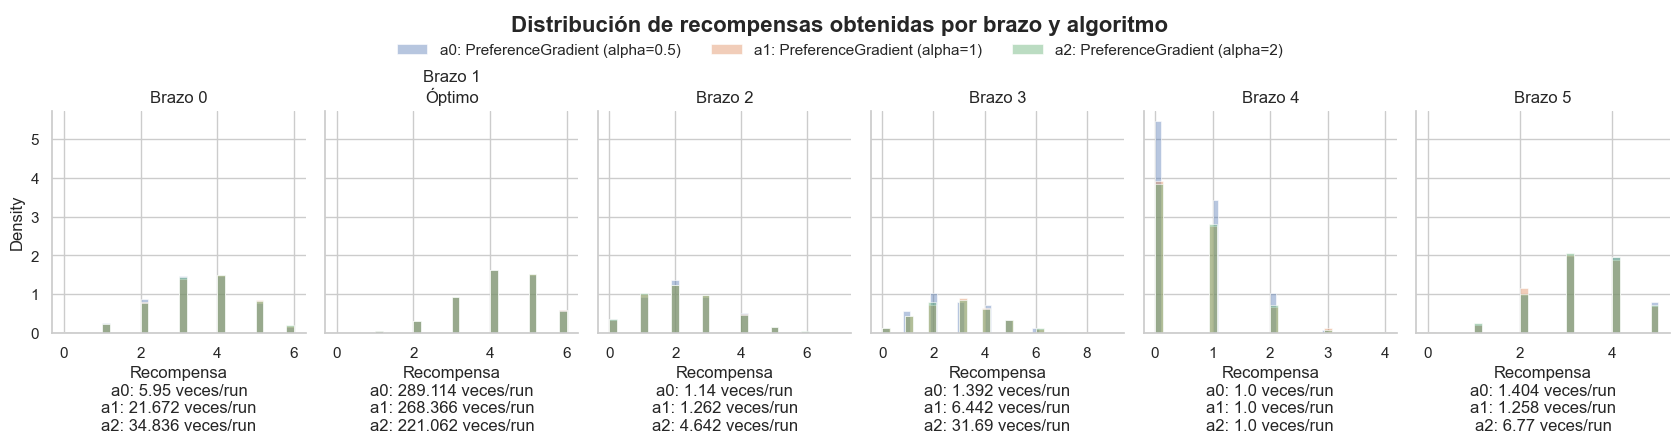

In [35]:
plot_arm_statistics(rewards_per_arm_per_algo_GBi, algorithms_gradient, runs, optimal_arm_binomial, kde=False)

Las estadísticas de cada brazo reflejan una tendencia similar a la que veíamos en la distribución normal: los algoritmos aprenden muy rápidamente cuál es el brazo óptimo y le dan mucha más prioridad que al resto de brazos. De hecho, hay brazos que han sido escogidos, de media, menos de 2 veces por ejecución; por ejemplo, el brazo 4 solo ha sido elegido una única vez en promedio por cada algoritmo, dado que es significativamente peor que los otros, como se aprecia en su histograma. Destaca especialmente cómo el mejor algoritmo ha sido capaz de distinguir mucho mejor el brazo óptimo del segundo mejor (esto es, el 1 del 0): mientras que los otros dos algoritmos han elegido el segundo mejor brazo en 21 y 35 ocasiones de media, $\text{PreferenceGradient}(alpha=0.5)$ solo lo ha escogido 6 veces.

### Distribución Bernoulli

Para finalizar el estudio, veamos cómo se comportan los algoritmos de Gradiente de Preferencias con brazos de distribución Bernoulli.

In [36]:
np.random.seed(SEMILLA)
rewards_GBe, optimal_selections_GBe, cumulative_regret_per_algo_GBe, rewards_per_arm_per_algo_GBe = run_experiment(bandit_bernoulli, algorithms_gradient, steps, runs)

100%|██████████| 500/500 [00:32<00:00, 15.22it/s]


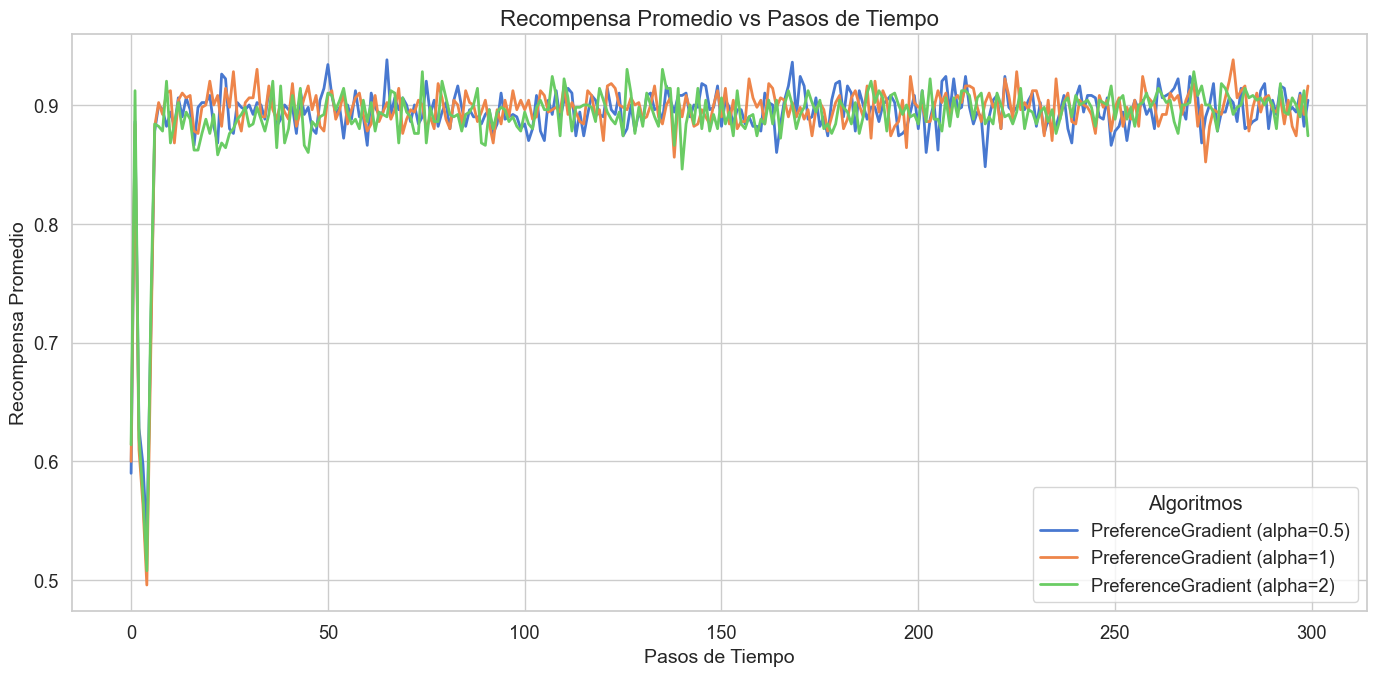

In [37]:
plot_average_rewards(steps, rewards_GBe, algorithms_gradient)

Al igual que veíamos en Softmax, el comportamiento de las tres versiones de los algoritmos de Gradiente de Preferencias es también muy parecido entre sí, apenas existe diferencia entre las recompensas promedio obtenidas para los tres valores de $\alpha$. Sin embargo, existe una diferencia muy clara con respecto a los algoritmos Softmax: en esta ocasión no se estancan en una recompensa promedio de alrededor de 0.7, sino que son capaces de llegar a la recompensa óptima esperada de 0.9 (con el segundo brazo). Además, el tiempo de aprendizaje es excepcionalmente pequeño, alcanzando la convergencia en unas 10 iteraciones.

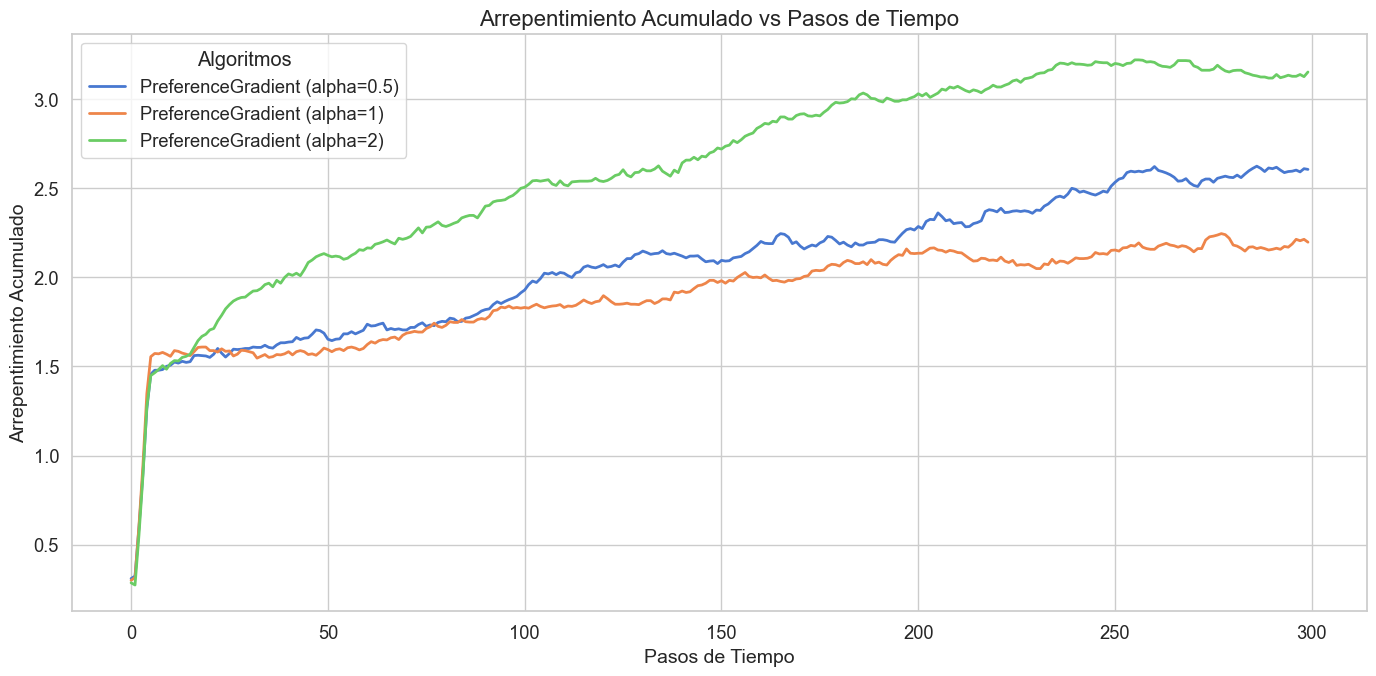

In [38]:
plot_regret(steps, cumulative_regret_per_algo_GBe, algorithms_gradient)

Mientras que las curvas de arrepentimiento acumulado de los algoritmos Softmax tenían una forma prácticamente lineal y diagonal, en este caso se aprecia más la tendencia logarítmica: empiezan creciendo muy rápido y a partir de cierto punto la velocidad de crecimiento se ralentiza considerablemente, y continúa decreciendo hasta el final de la gráfica. Esto significa que, aunque no lo parecía en la gráfica de recompensas promedio, los algoritmos aprenden durante la totalidad de su ejecución, aunque a un ritmo muy lento. El arrepentimiento acumulado máximo en este caso es cercano a 3.0, lo cual es un resultado extraordinario (en los algoritmos Softmax, este valor era de 70).

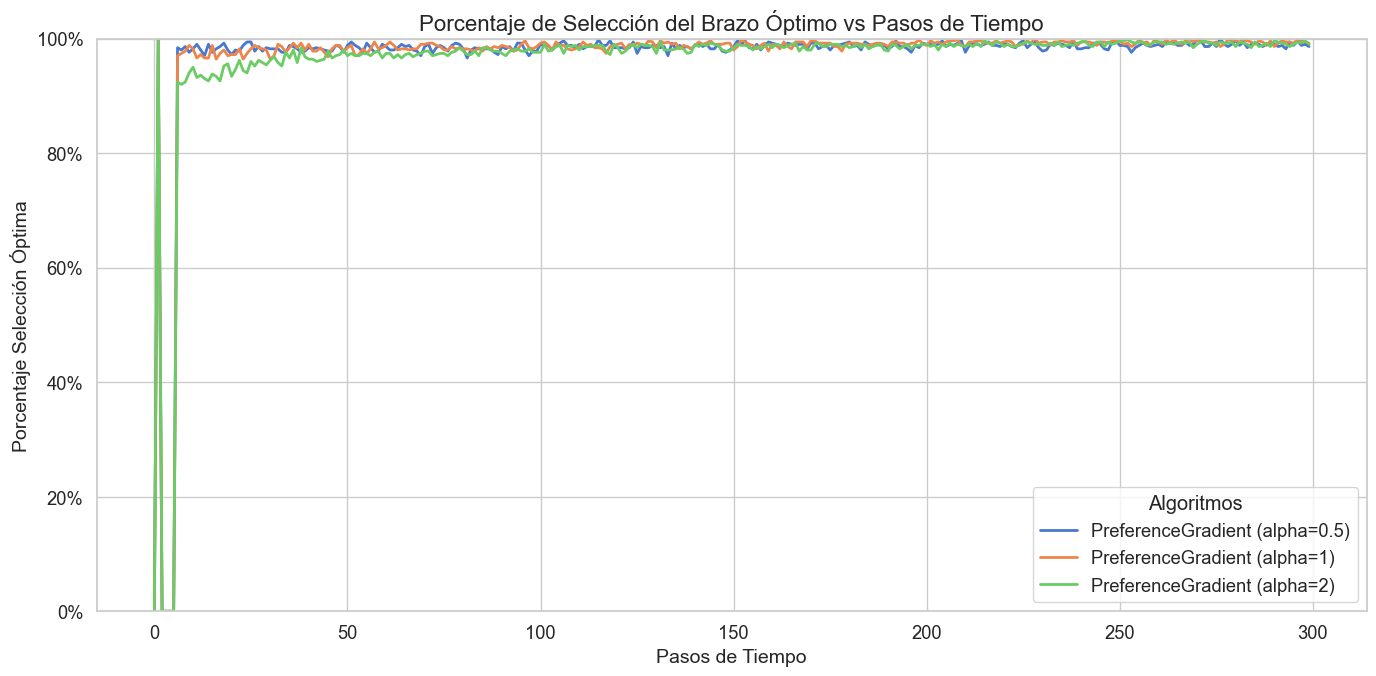

In [39]:
plot_optimal_selections(steps, optimal_selections_GBe, algorithms_gradient)

Como no podía ser de otra manera, el porcentaje de selección del brazo óptimo para las tres variantes es de prácticamente el 100% durante la gran mayoría de los pasos de ejecución. En los Softmax, este valor se quedaba en un 20%.

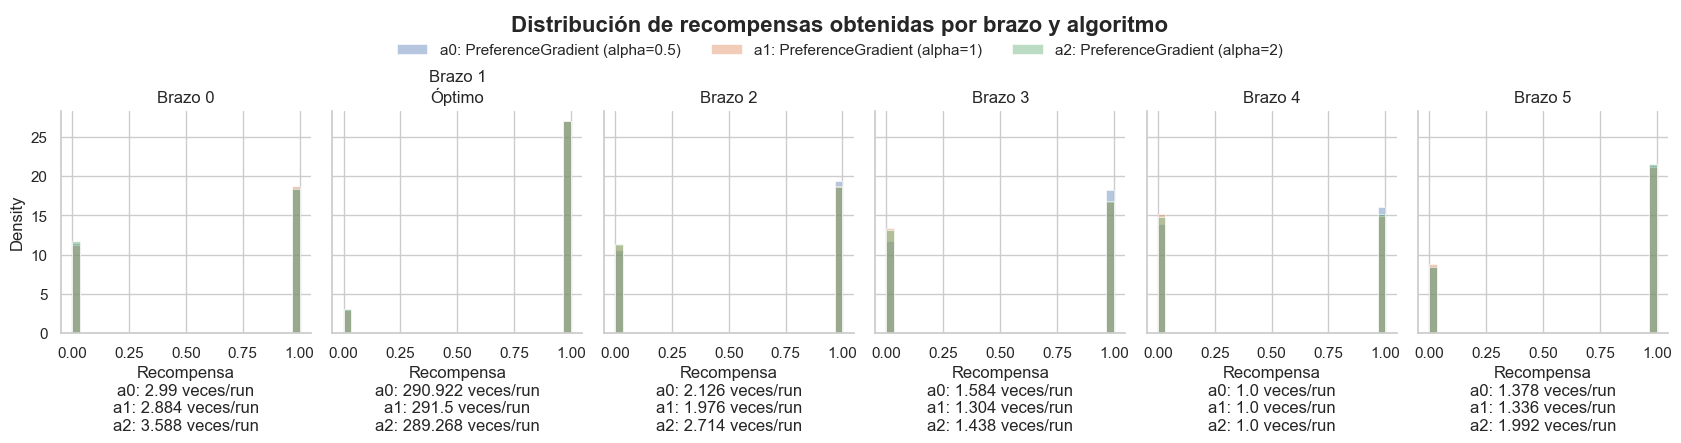

In [40]:
plot_arm_statistics(rewards_per_arm_per_algo_GBe, algorithms_gradient, runs, optimal_arm_bernoulli, kde=False)

Esta última gráfica reitera lo que ya hemos mencionado antes: los tres algoritmos aprenden rápidamente cuál es el brazo óptimo y le dan mucha más preferencia que a los demás, incluso el algoritmo con $\alpha=2$. Por tanto, vemos que el Gradiente de Preferencias parece funcionar mucho mejor que el Softmax para brazos con distribución Bernoulli.

## Conclusiones

En este estudio hemos comparado el rendimiento de dos tipos de algoritmos en el problema del bandido de los k-brazos: Softmax y Gradiente de Preferencias. Cada uno ha sido evaluado con bandidos de 6 brazos de distribuciones normal, binomial y Bernoulli, y hemos podido extraer las siguientes conclusiones al respecto:

- Ambos algoritmos se probaron con valores de parámetros igual a 0.5, 1 y 2, y todos ellos funcionaron mejor con los valores más bajos. En el caso de Softmax, esto implica que se debe primar más la explotación que la exploración y, para el Gradiente de Preferencias, significa que el paso de las actualizaciones debe ser pequeño.

- El algoritmo Softmax presentó una mayor diferencia entre sus tres versiones, en especial para el caso de las distribuciones normales, y se comportó mejor para el bandido de dsitribución binomial. Sin embargo, su rendimiento fue muy pobre en la distribución Bernoulli.

- El Gradiente de Preferencias no presentó diferencias tan notables entre las tres variantes, con la peor de todas comportándose bastante mejor que la peor versión del algoritmo Softmax. En este caso, el algoritmo sobresalió especialmente para la distribución Bernoulli, en la cual consiguió alcanzar una solución óptima en las tres versiones con muy pocos pasos de aprendizaje.

- El algoritmo de Gradiente de Preferencias superó al Softmax en todos los experimentos y métricas analizadas, y con un tiempo de ejecución casi idéntico.

Por consiguiente, queda claro que dentro de la familia de algoritmos de ascenso de gradiente, el de Gradiente de Preferencias es más recomendable para las tres distribuciones de probabilidad que han sido estudiadas.

## Referencias

<span id="apuntes">[1]</span> Hernández Molinero, L. D. (2025), *"Aprendizaje por Refuerzo. Bandido Multibrazo"*. Asignatura de Extensiones de Machine Learning, Universidad de Murcia.

<span id="suttonbarto">[2]</span> Sutton, R., Barto, A. (2018), *"Reinforcement Learning, second edition: An Introduction"*. MIT Press. https://web.stanford.edu/class/psych209/Readings/SuttonBartoIPRLBook2ndEd.pdf
